# 07 - NCF Training: Neural Collaborative Filtering

Treina o modelo principal do projeto (PyTorch, embedding-based) com negative sampling e random search de hiperparâmetros. Ver `docs/NOTEBOOKS.md` (seção 7) para a justificativa da arquitetura.

## 0. Configuração Inicial

In [1]:
import copy
import json
import pickle
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.optim as optim
import yaml
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, str(Path("..").resolve()))
from src.evaluation.metrics import evaluate_recommendations, pairs_to_ground_truth
from src.evaluation.ranking import recommendations_from_score_matrix
from src.models.ncf import NeuralCollaborativeFiltering, score_all_items

RANDOM_SEED = 42


def set_seed(seed: int) -> None:
    """Fixa a seed de aleatoriedade para reprodutibilidade (numpy, random, torch)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(RANDOM_SEED)

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models/neural_network")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open("../configs/model_config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)
K = config["evaluation"]["k"]
NCF_CFG = config["ncf"]
SEARCH_CFG = NCF_CFG["search"]

mlflow.set_tracking_uri(f"file:{(Path('..') / 'mlruns').resolve()}")
mlflow.set_experiment("ncf")

print(NCF_CFG)

{'embedding_dim': 32, 'hidden_dims': [128, 64, 32], 'negative_ratio': 4, 'learning_rate': 0.005, 'batch_size': 16384, 'epochs': 15, 'early_stopping_patience': 4, 'val_sample_size': 1500, 'search': {'enabled': True, 'n_trials': 4, 'search_epochs': 5, 'search_early_stopping_patience': 2, 'learning_rate_choices': [0.001, 0.003, 0.005, 0.01], 'embedding_dim_choices': [16, 32, 64], 'hidden_dims_choices': [[64, 32], [128, 64, 32], [256, 128, 64]]}}


## 1. Carregamento dos Artefatos de Preprocessing

In [2]:
with open(PROCESSED_DIR / "vocabularies.pkl", "rb") as f:
    vocab = pickle.load(f)
with open(PROCESSED_DIR / "split_meta.json", encoding="utf-8") as f:
    split_meta = json.load(f)

interactions_prior = sp.load_npz(PROCESSED_DIR / "interactions_prior.npz")
train_pairs = pd.read_pickle(PROCESSED_DIR / "train_pairs.pkl")
val_pairs = pd.read_pickle(PROCESSED_DIR / "val_pairs.pkl")
test_pairs = pd.read_pickle(PROCESSED_DIR / "test_pairs.pkl")

n_users, n_items = interactions_prior.shape
val_ground_truth = pairs_to_ground_truth(val_pairs)
test_ground_truth = pairs_to_ground_truth(test_pairs)

print(f"n_users={n_users:,} | n_items={n_items:,} | train_pairs={len(train_pairs):,}")

n_users=126,408 | n_items=3,000 | train_pairs=689,910


## 2. Negative Sampling Uniforme

**Decisão de design:** a primeira versão deste notebook usava negative sampling ponderado pela popularidade (itens populares tinham maior chance de serem sorteados como negativos). Isso se mostrou contraproducente neste dataset: como o comportamento de recompra do Instacart favorece fortemente itens populares (ver `01_eda.ipynb`), penalizar repetidamente esses itens como negativos ensinou o modelo a *suprimir* exatamente os itens mais relevantes — o NCF terminou pior que o baseline de popularidade. A amostragem foi trocada para **uniforme** sobre o catálogo, removendo esse viés.

In [3]:
def build_epoch_dataset(
    train_pairs: pd.DataFrame,
    n_items: int,
    negative_ratio: int,
    rng: np.random.Generator,
) -> TensorDataset:
    """Constroi o dataset de uma epoca: positivos + negativos uniformes.

    Args:
        train_pairs: pares positivos (user_idx, item_idx) de treino.
        n_items: tamanho do catalogo de itens.
        negative_ratio: numero de negativos amostrados por positivo.
        rng: gerador de numeros aleatorios (seed fixa por epoca).

    Returns:
        TensorDataset com colunas (user_idx, item_idx, label).
    """
    pos_users = train_pairs["user_idx"].to_numpy()
    pos_items = train_pairs["item_idx"].to_numpy()
    neg_users = np.repeat(pos_users, negative_ratio)
    neg_items = rng.integers(0, n_items, size=len(neg_users))

    users = np.concatenate([pos_users, neg_users])
    items = np.concatenate([pos_items, neg_items])
    labels = np.concatenate([np.ones(len(pos_users)), np.zeros(len(neg_users))])
    return TensorDataset(
        torch.tensor(users, dtype=torch.long),
        torch.tensor(items, dtype=torch.long),
        torch.tensor(labels, dtype=torch.float32),
    )

## 3. Amostra de Validação (Early Stopping e Random Search)

Avaliar todos os usuários de validação a cada época/trial seria caro (score em todos os 3.000 itens). Por isso, tanto o random search quanto o early stopping usam uma amostra fixa (seed 42); a avaliação final completa (seção 8) usa a população total de validação/teste.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
val_users_all = list(val_ground_truth.keys())
val_sample_size = min(NCF_CFG["val_sample_size"], len(val_users_all))
val_sample = rng.choice(val_users_all, size=val_sample_size, replace=False).tolist()
val_sample_ground_truth = {u: val_ground_truth[u] for u in val_sample}

print(f"Amostra de validacao: {len(val_sample):,} usuarios")

Amostra de validacao: 1,500 usuarios


## 4. Funções de Treino e Avaliação Reutilizáveis

In [5]:
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, loss_fn) -> float:
    """Executa uma epoca de treino e retorna a loss media."""
    model.train()
    total_loss = 0.0
    for users, items, labels in loader:
        optimizer.zero_grad()
        preds = model(users, items)
        loss = loss_fn(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(users)
    return total_loss / len(loader.dataset)


def evaluate_sample(
    model: nn.Module, user_indices: list, ground_truth: dict, n_items: int, k: int
) -> dict:
    """Avalia o modelo em uma amostra de usuarios via score_all_items."""
    scores = score_all_items(model, user_indices, n_items)
    recs = recommendations_from_score_matrix(user_indices, scores, k)
    return evaluate_recommendations(recs, ground_truth, k)

In [6]:
def run_training(
    embedding_dim: int,
    hidden_dims: tuple,
    learning_rate: float,
    epochs: int,
    patience: int,
) -> tuple:
    """Treina um NCF do zero com early stopping na amostra de validacao.

    Args:
        embedding_dim: dimensao dos embeddings de usuario/item.
        hidden_dims: tamanhos das camadas ocultas do MLP.
        learning_rate: taxa de aprendizado do Adam.
        epochs: numero maximo de epocas.
        patience: paciencia do early stopping.

    Returns:
        Tupla (modelo com melhores pesos, historico por epoca, melhor recall@k).
    """
    model = NeuralCollaborativeFiltering(n_users, n_items, embedding_dim, hidden_dims)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.BCELoss()

    history, best_recall, best_state, patience_counter = [], -1.0, None, 0
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        epoch_rng = np.random.default_rng(RANDOM_SEED + epoch)
        dataset = build_epoch_dataset(
            train_pairs, n_items, NCF_CFG["negative_ratio"], epoch_rng
        )
        loader = DataLoader(dataset, batch_size=NCF_CFG["batch_size"], shuffle=True)

        train_loss = train_one_epoch(model, loader, optimizer, loss_fn)
        val_metrics = evaluate_sample(
            model, val_sample, val_sample_ground_truth, n_items, K
        )
        epoch_time = time.time() - epoch_start

        record = {"epoch": epoch, "train_loss": train_loss, "epoch_time_s": epoch_time}
        record.update(val_metrics)
        history.append(record)

        if val_metrics["recall_at_k"] > best_recall:
            best_recall = val_metrics["recall_at_k"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, history, best_recall

## 5. Random Search de Hiperparâmetros (Validação)

Busca aleatória sobre `learning_rate`, `embedding_dim` e `hidden_dims`, com poucas épocas (`search_epochs`) para manter o custo viável. Avaliada apenas na amostra de validação — nunca no teste.

In [7]:
search_rng = random.Random(RANDOM_SEED)
all_combos = [
    (lr, dim, tuple(hd))
    for lr in SEARCH_CFG["learning_rate_choices"]
    for dim in SEARCH_CFG["embedding_dim_choices"]
    for hd in SEARCH_CFG["hidden_dims_choices"]
]
trial_combos = search_rng.sample(all_combos, k=SEARCH_CFG["n_trials"])

search_results = []
for trial_idx, (lr, dim, hidden_dims) in enumerate(trial_combos):
    _, trial_history, trial_best_recall = run_training(
        embedding_dim=dim,
        hidden_dims=hidden_dims,
        learning_rate=lr,
        epochs=SEARCH_CFG["search_epochs"],
        patience=SEARCH_CFG["search_early_stopping_patience"],
    )
    search_results.append(
        {
            "learning_rate": lr,
            "embedding_dim": dim,
            "hidden_dims": hidden_dims,
            "best_val_recall_at_k": trial_best_recall,
            "epochs_run": len(trial_history),
        }
    )
    with mlflow.start_run(run_name=f"search_trial_{trial_idx}"):
        mlflow.log_params(
            {"learning_rate": lr, "embedding_dim": dim, "hidden_dims": str(hidden_dims)}
        )
        mlflow.log_metric("best_val_recall_at_k", trial_best_recall)
    print(f"trial {trial_idx}: lr={lr} dim={dim} hidden={hidden_dims}")
    print(f"  -> best_val_recall_at_k={trial_best_recall:.4f}")

search_df = pd.DataFrame(search_results)
search_df = search_df.sort_values("best_val_recall_at_k", ascending=False)
best_trial = search_df.iloc[0]
print(search_df)

trial 0: lr=0.001 dim=64 hidden=(128, 64, 32)
  -> best_val_recall_at_k=0.0939


trial 1: lr=0.001 dim=16 hidden=(128, 64, 32)
  -> best_val_recall_at_k=0.0942


trial 2: lr=0.003 dim=64 hidden=(256, 128, 64)
  -> best_val_recall_at_k=0.0950


trial 3: lr=0.003 dim=64 hidden=(64, 32)
  -> best_val_recall_at_k=0.0937
   learning_rate  embedding_dim     hidden_dims  best_val_recall_at_k  \
2          0.003             64  (256, 128, 64)              0.095042   
1          0.001             16   (128, 64, 32)              0.094185   
0          0.001             64   (128, 64, 32)              0.093948   
3          0.003             64        (64, 32)              0.093651   

   epochs_run  
2           5  
1           5  
0           5  
3           4  


## 6. Treinamento Final com os Melhores Hiperparâmetros

In [8]:
best_embedding_dim = int(best_trial["embedding_dim"])
best_hidden_dims = tuple(best_trial["hidden_dims"])
best_learning_rate = float(best_trial["learning_rate"])

model, history, best_recall = run_training(
    embedding_dim=best_embedding_dim,
    hidden_dims=best_hidden_dims,
    learning_rate=best_learning_rate,
    epochs=NCF_CFG["epochs"],
    patience=NCF_CFG["early_stopping_patience"],
)

print(f"Config final: lr={best_learning_rate}, dim={best_embedding_dim}")
print(f"hidden={best_hidden_dims}")
print(f"Melhor val_recall_at_k (amostra): {best_recall:.4f} em {len(history)} epocas")

Config final: lr=0.003, dim=64
hidden=(256, 128, 64)
Melhor val_recall_at_k (amostra): 0.0950 em 11 epocas


## 7. Curvas de Treinamento (Configuração Final)

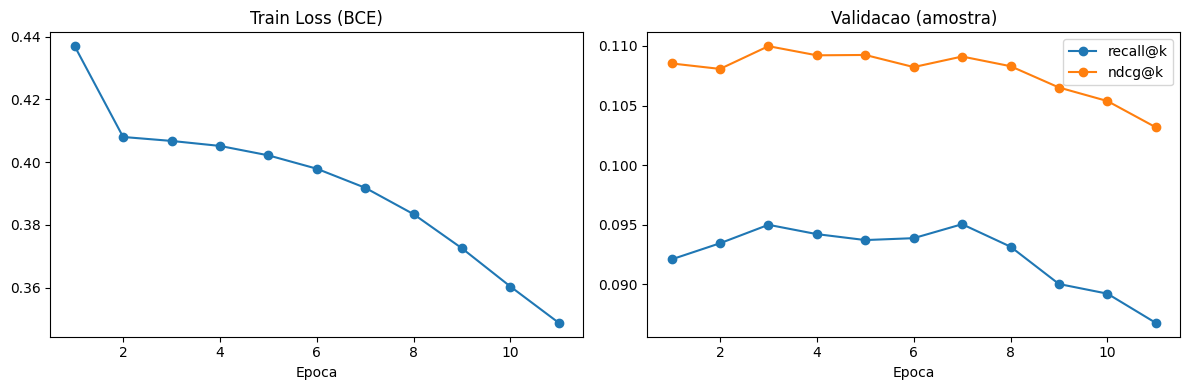

In [9]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
axes[0].set_title("Train Loss (BCE)")
axes[0].set_xlabel("Epoca")

axes[1].plot(
    history_df["epoch"], history_df["recall_at_k"], marker="o", label="recall@k"
)
axes[1].plot(history_df["epoch"], history_df["ndcg_at_k"], marker="o", label="ndcg@k")
axes[1].set_title("Validacao (amostra)")
axes[1].set_xlabel("Epoca")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Avaliação Final Completa (Validação e Teste)

In [10]:
val_scores = score_all_items(model, list(val_ground_truth.keys()), n_items)
val_recommendations = recommendations_from_score_matrix(
    list(val_ground_truth.keys()), val_scores, K
)
val_metrics = evaluate_recommendations(val_recommendations, val_ground_truth, K)

test_scores = score_all_items(model, list(test_ground_truth.keys()), n_items)
test_recommendations = recommendations_from_score_matrix(
    list(test_ground_truth.keys()), test_scores, K
)
test_metrics = evaluate_recommendations(test_recommendations, test_ground_truth, K)

print("Validacao (completa):", val_metrics)
print("Teste (completo):", test_metrics)

Validacao (completa): {'precision_at_k': 0.07628289647170508, 'recall_at_k': 0.09356690732039921, 'ndcg_at_k': 0.11124731301463749, 'map_at_k': 0.053077835419865486}
Teste (completo): {'precision_at_k': 0.07498154203143129, 'recall_at_k': 0.09295480410802218, 'ndcg_at_k': 0.10930593828320431, 'map_at_k': 0.05185015444854515}


## 9. Persistência e Rastreamento no MLflow (Model Registry: Staging)

In [11]:
torch.save(model.state_dict(), MODELS_DIR / "best_model.pt")
torch.save(model.state_dict(), MODELS_DIR / "model.pt")
with open(MODELS_DIR / "training_history.pkl", "wb") as f:
    pickle.dump(history, f)

final_params = {
    "embedding_dim": best_embedding_dim,
    "hidden_dims": list(best_hidden_dims),
    "learning_rate": best_learning_rate,
    "negative_ratio": NCF_CFG["negative_ratio"],
    "batch_size": NCF_CFG["batch_size"],
}
metrics_payload = {
    "k": K,
    "params": final_params,
    "search_results": search_results,
    "validation": val_metrics,
    "test": test_metrics,
}
with open(MODELS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

with mlflow.start_run(run_name="ncf_final") as run:
    mlflow.log_params(
        {**final_params, "k": K, "dataset_hash": split_meta["dataset_hash"]}
    )
    for record in history:
        epoch = record["epoch"]
        mlflow.log_metric("train_loss", record["train_loss"], step=epoch)
        mlflow.log_metric("val_recall_at_k_sample", record["recall_at_k"], step=epoch)
        mlflow.log_metric("val_ndcg_at_k_sample", record["ndcg_at_k"], step=epoch)
    mlflow.log_metrics({f"val_{name}": value for name, value in val_metrics.items()})
    mlflow.log_metrics({f"test_{name}": value for name, value in test_metrics.items()})
    mlflow.log_artifact(str(MODELS_DIR / "metrics.json"))
    mlflow.pytorch.log_model(model, "model", registered_model_name="ncf_recommender")

client = mlflow.tracking.MlflowClient()
latest_version = client.get_latest_versions("ncf_recommender")[0].version
client.transition_model_version_stage("ncf_recommender", latest_version, "Staging")

print(
    f"NCF (versao {latest_version}) registrado no MLflow Model Registry como Staging."
)

2026/06/21 18:31:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.1+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.12.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


2026/06/21 18:31:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.1+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.12.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


2026/06/21 18:31:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/06/21 18:31:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Registered model 'ncf_recommender' already exists. Creating a new version of this model...


Created version '3' of model 'ncf_recommender'.


NCF (versao 3) registrado no MLflow Model Registry como Staging.


C:\Users\willi\AppData\Local\Temp\ipykernel_25932\2453297405.py:38: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions("ncf_recommender")[0].version
C:\Users\willi\AppData\Local\Temp\ipykernel_25932\2453297405.py:39: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage("ncf_recommender", latest_version, "Staging")
